# 01b — Grandes Modelos de Lenguaje e Inferencia

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/01b-llms.ipynb)

> Este tema forma parte del **Bloque 1 — Fundamentos**. Se recomienda
> haber visto primero [01a-transformer.qmd](01a-transformer.qmd).

In [1]:
!pip install -q transformers langchain-openai requests matplotlib


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")


## Grandes Modelos de Lenguaje (LLMs)

### Preentrenamiento

Los LLMs se preentrenan con un objetivo aparentemente simple: **predecir
el siguiente token** (next token prediction). Dada una secuencia de
tokens $t_1, t_2, ..., t_n$, el modelo aprende a maximizar la
probabilidad de $t_{i+1}$ dados los tokens anteriores:

$$P(t_{i+1} | t_1, ..., t_i)$$

De este proceso emergen capacidades complejas: sintaxis, semántica,
razonamiento, conocimiento factual. Las **scaling laws** (Kaplan et al.,
2020) demostraron que el rendimiento mejora de forma predecible al
escalar: - Número de parámetros del modelo - Tamaño del dataset de
entrenamiento - Cómputo total

### Tokenización

Los modelos no procesan caracteres ni palabras directamente, sino
**tokens**: unidades subpalabra que equilibran cobertura del vocabulario
y eficiencia.

| Algoritmo | Cómo funciona | Usado en |
|------------------------|------------------------|------------------------|
| **BPE** (Byte-Pair Encoding) | Fusiona iterativamente los pares de caracteres más frecuentes | GPT, GPT-2 |
| **WordPiece** | Similar a BPE pero fusiona por máxima verosimilitud | BERT |
| **SentencePiece** | Trata el texto como bytes, no requiere pre-tokenización | Llama, T5, Gemma |
| **BPE (Qwen)** | Variante de BPE con vocabulario extendido para multilingüismo | Qwen 3.6, Qwen 3 |

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
texto = "La IA Generativa está transformando el Data Science"

tokens = tokenizer.tokenize(texto)
ids = tokenizer.encode(texto)

print(f"Texto original: {texto}")
print(f"Número de tokens: {len(tokens)}")
print(f"\nTokens: {tokens}")
print(f"IDs:     {ids}")
print(f"\nDecodificado: {tokenizer.decode(ids)}")


### Ventana de contexto

La **ventana de contexto** es el número máximo de tokens que el modelo
puede procesar en una sola pasada. Limitaciones prácticas: -
**Memoria:** la atención es O(n²) en memoria (sin optimizaciones) -
**Modelos tempranos:** GPT-2 (1024), GPT-3 (2048), GPT-4 (8192) -
**Modelos actuales:** Llama 3 (8K), Qwen 3.6 (128K), DeepSeek R1 (128K),
Gemini (32K-1M), Claude (100K-200K)

Técnicas de extensión: RoPE (Rotary Position Embedding), ALiBi,
windowing, y atención dispersa.

### Parámetros de inferencia

Controlan cómo el modelo selecciona el siguiente token entre las
probabilidades de salida.

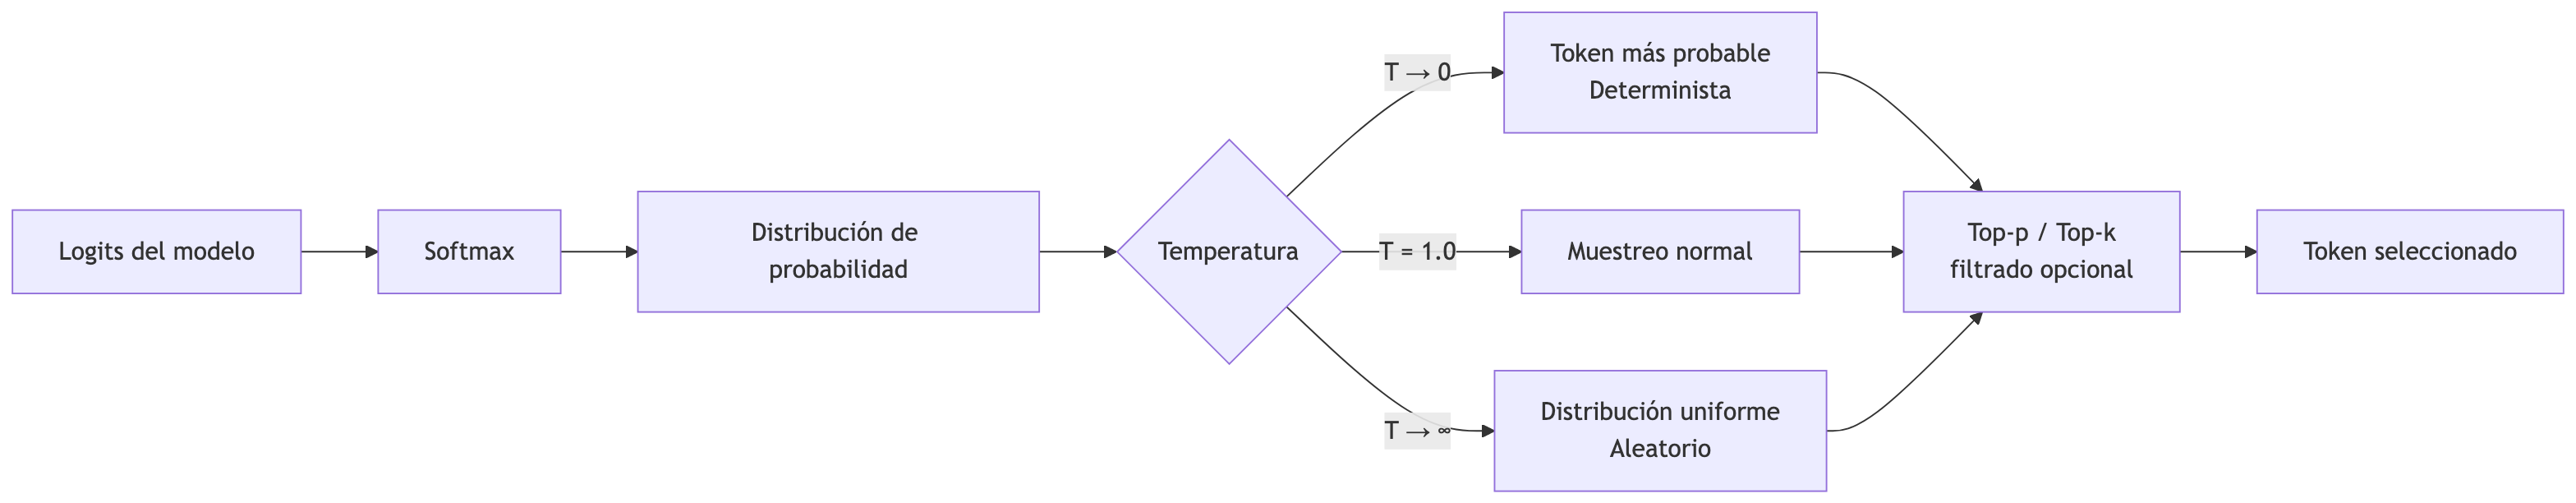

In [4]:
from langchain_openai import ChatOpenAI

# Usamos la API unificada de la Universidad de Sevilla (Llamus)
# No necesita GPU — solo una API key que obtendrás en la asignatura
llm = ChatOpenAI(
    model="gemma4:e2b-mlx",
    base_url="https://llamus.cs.us.es/api/v1",
    api_key="<API_KEY>"
)

for temp in [0.1, 0.7, 1.5]:
    llm.temperature = temp
    resp = llm.invoke("El futuro de la inteligencia artificial")
    print(f"Temperatura {temp:.1f}: {resp.content[:100]}...")
    print()


In [5]:
# Visualizar el efecto de la temperatura en la distribución
logits = torch.randn(10) * 2  # logits simulados

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, temp in enumerate([0.1, 1.0, 2.0]):
    probs = torch.softmax(logits / temp, dim=0).numpy()
    axes[i].bar(range(10), probs)
    axes[i].set_title(f"Temperatura = {temp}")
    axes[i].set_ylim(0, 1)
    axes[i].set_xlabel("Token")
    axes[i].set_ylabel("Probabilidad")

plt.tight_layout()
plt.show()


> **Parámetros clave en producción**
>
> - **Temperatura:** controla la creatividad. Baja (0.1-0.3) para tareas
>   factuales, alta (0.7-0.9) para creatividad.
> - **Top-p (nucleus sampling):** selecciona del subconjunto de tokens
>   cuya probabilidad acumulada suma p. típico: 0.9-0.95.
> - **Top-k:** limita la selección a los k tokens más probables. típico:
>   40-50.
> - Combinación común: temp=0.7, top-p=0.9, top-k=40.

### Más allá del texto: el LLM como modelo generativo

Un LLM no es más que un modelo que aprende una distribución de
probabilidad $P(\text{token} \mid \text{contexto})$ y muestrea de ella.
Esta misma idea —aprender la distribución subyacente de los datos y
generar nuevas muestras— es el **principio unificador de todos los
modelos generativos**:

| Modelo | ¿Qué aprende? | ¿Qué genera? |
|------------------------|------------------------|------------------------|
| **LLM** (GPT, Qwen, Llama) | $P(\text{token} \mid \text{contexto})$ | Texto, código, JSON, datos tabulares |
| **GAN** (CTGAN, CopulaGAN) | Distribución implícita vía juego adversarial | Datos tabulares |
| **VAE** (TVAE) | Espacio latente comprimido de los datos | Datos tabulares |
| **Difusión** (TabDDPM) | Proceso inverso de eliminación de ruido | Datos tabulares, imágenes |

Lo que acabas de entender sobre la temperatura es el equivalente
conceptual a:

- La varianza del ruido en una VAE (controla diversidad)
- El muestreo del espacio latente en una GAN (controla realismo
  vs. variedad)
- El nivel de ruido en un modelo de difusión (controla fidelidad)

En el **Bloque 2** verás cómo usar LLMs para generar datos sintéticos de
forma intuitiva (sin entrenar nada), y en el **Bloque 3** explorarás
modelos especializados (GANs, VAEs, difusión) para cuando necesites
rigor estadístico y garantías de privacidad.

## El ecosistema Hugging Face

[Hugging Face Hub](https://huggingface.co/models) es el repositorio más
grande de modelos preentrenados del mundo. Puedes navegar por **task**
(text generation, feature extraction, image classification),
**framework** (PyTorch, TensorFlow), **licencia** (MIT, Apache 2.0,
Llama 2 Community) y **popularidad**.

Para cada modelo encontrarás: - **Model Card**: descripción,
arquitectura, dataset de entrenamiento, benchmark esperado - **Code
snippets**: carga con `transformers`, `sentence-transformers` o API -
**Spaces**: demos interactivas para probar el modelo sin instalar nada -
**Licencia**: crucial para uso comercial vs. académico

``` bash
# Explorar modelos por task: huggingface.co/models?pipeline_tag=text-generation
# El Hub permite filtrar por framework, licencia, idioma y popularidad
```

> **Nota:** No necesitas descargar modelos localmente. En este módulo
> usarás la **API unificada de la Universidad de Sevilla** para hacer
> inferencia sobre modelos modernos sin necesidad de GPU.

### Modelos privados vs. open-weight vs. open-source

No todos los modelos “abiertos” lo son realmente. Existe una distinción
clave entre cómo se accede al modelo y qué permisos otorga:

| Tipo | Acceso a pesos | Ejemplos | Licencia típica |
|------------------|------------------|------------------|------------------|
| **Privado** | Solo API (nunca ves los pesos) | GPT-4o, Claude 4, Gemini 2.5 | Términos de servicio |
| **Open-weight** | Pesos descargables, pero con restricciones de uso | Qwen 3.6, Gemma 4, Llama 3.3, DeepSeek R1 | Licencia específica (Llama 2 Community, Gemma ToS, DeepSeek License) |
| **Open-source** | Pesos + código fuente + datos de entrenamiento | OLMo 2, Pythia, Bloom, Falcon | OSI-approved (Apache 2.0, MIT) |

**Puntos clave:**

- **Open-weight ≠ open-source.** Que puedas descargar los pesos no
  implica que puedas usarlos sin restricciones. La mayoría de modelos
  “abiertos” tienen limitaciones: prohibición de uso para grandes
  empresas (\>700M MAU en Llama), restricciones comerciales, o cláusulas
  de no competencia.
- **Hugging Face Hub** permite filtrar por licencia
  (`huggingface.co/models?license=apache-2.0,mit`), lo que facilita
  encontrar modelos realmente open-source.
- **Modelos privados** (vía API): no requieren infraestructura, pero
  generan dependencia del proveedor, coste por token, y posibles
  problemas de privacidad de datos.
- **Modelos open-weight/open-source:** puedes alojarlos tú mismo
  (Ollama, vLLM), inspeccionar los pesos, hacer fine-tuning, pero
  requieren infraestructura GPU y conocimiento técnico.

``` bash
# En HF puedes filtrar por licencia:
#   open-source real: huggingface.co/models?license=apache-2.0,mit
#   open-weight: huggingface.co/models?license=llama2,gemma
```

> En este módulo usarás **modelos open-weight** (Qwen 3.6, Gemma 4,
> Llama 3.3) a través de la API de Llamus. Desde el código la diferencia
> es mínima, pero es crucial entender las implicaciones de licencias al
> elegir un modelo para un proyecto profesional.

## Inferencia con la API unificada de la US (Llamus)

La Universidad de Sevilla proporciona un endpoint **OpenAI-compatible**
para usar LLMs sin necesidad de GPU local:

    Endpoint: https://llamus.cs.us.es/api/v1
    Modelos disponibles: gemma4:e2b-mlx, gemma4:26b, llama3.3:70b, ...

Funciona con `ChatOpenAI` de LangChain, el cliente OpenAI de Python, o
cualquier herramienta compatible con OpenAI. Solo necesitas tu **API key
de la US** (se proporciona en la asignatura).

In [6]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gemma4:e2b-mlx",   # Modelo principal del curso
    base_url="https://llamus.cs.us.es/api/v1",
    api_key="<API_KEY>"
)

resp = llm.invoke("Explica qué es un Transformer en 3 frases")
print(resp.content)


In [7]:
# También puedes consultar los modelos disponibles
import requests

r = requests.get("https://llamus.cs.us.es/api/v1/models",
                  headers={"Authorization": "Bearer <API_KEY>"})
models = r.json()
for m in models["data"]:
    print(f"  • {m['id']}")


> **Ventajas de usar Llamus**
>
> - **Sin GPU:** todo corre en servidores de la US
> - **Modelos actualizados:** Qwen 3.6, Gemma 4, Llama 3.3, DeepSeek…
> - **OpenAI-compatible:** mismo código que con cualquier API comercial
> - **Gratuito para alumnos de la US** con tu API key institucional

------------------------------------------------------------------------

> Continúa con **[01c-embeddings.qmd](01c-embeddings.qmd)** — Modelos de
> Embeddings.